In [6]:
import pandas as pd

In [7]:
df=pd.read_csv('D:\machine_learning\datasets\electricity_cost_dataset.csv')

In [8]:
df

,site area,structure type,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,Mixed-use,2519.0,69,52,188,1,72,1420.0
1,4272,Mixed-use,2324.0,50,76,165,65,261,3298.0
2,3592,Mixed-use,2701.0,20,94,198,39,117,3115.0
3,966,Residential,1000.0,13,60,74,3,35,1575.0
4,4926,Residential,5990.0,23,65,32,57,185,4301.0
...,...,...,...,...,...,...,...,...,...
9995,708,Commercial,1365.0,76,77,22,23,0,885.0
9996,2960,Residential,3332.0,22,72,100,47,54,3081.0
9997,3942,Commercial,2427.0,61,43,48,49,0,3325.0
9998,3211,Commercial,4639.0,72,73,105,55,0,2892.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site area             10000 non-null  int64  
 1   structure type        10000 non-null  object 
 2   water consumption     10000 non-null  float64
 3   recycling rate        10000 non-null  int64  
 4   utilisation rate      10000 non-null  int64  
 5   air qality index      10000 non-null  int64  
 6   issue reolution time  10000 non-null  int64  
 7   resident count        10000 non-null  int64  
 8   electricity cost      10000 non-null  float64
dtypes: float64(2), int64(6), object(1)
memory usage: 703.3+ KB


In [11]:
df=df.drop(columns='structure type')

In [12]:
df

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
0,1360,2519.0,69,52,188,1,72,1420.0
1,4272,2324.0,50,76,165,65,261,3298.0
2,3592,2701.0,20,94,198,39,117,3115.0
3,966,1000.0,13,60,74,3,35,1575.0
4,4926,5990.0,23,65,32,57,185,4301.0
...,...,...,...,...,...,...,...,...
9995,708,1365.0,76,77,22,23,0,885.0
9996,2960,3332.0,22,72,100,47,54,3081.0
9997,3942,2427.0,61,43,48,49,0,3325.0
9998,3211,4639.0,72,73,105,55,0,2892.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site area             10000 non-null  int64  
 1   water consumption     10000 non-null  float64
 2   recycling rate        10000 non-null  int64  
 3   utilisation rate      10000 non-null  int64  
 4   air qality index      10000 non-null  int64  
 5   issue reolution time  10000 non-null  int64  
 6   resident count        10000 non-null  int64  
 7   electricity cost      10000 non-null  float64
dtypes: float64(2), int64(6)
memory usage: 625.1 KB


In [14]:
df.corr()

,site area,water consumption,recycling rate,utilisation rate,air qality index,issue reolution time,resident count,electricity cost
site area,1.000000,0.745372,0.006786,0.019681,-0.003770,0.007520,0.360160,0.874376
water consumption,0.745372,1.000000,0.006977,0.008711,0.000929,0.007786,0.281256,0.698775
recycling rate,0.006786,0.006977,1.000000,-0.022350,-0.011125,-0.005641,-0.008540,-0.012536
utilisation rate,0.019681,0.008711,-0.022350,1.000000,-0.008747,-0.000795,0.012424,0.207215
air qality index,-0.003770,0.000929,-0.011125,-0.008747,1.000000,-0.027277,0.013728,0.017376
issue reolution time,0.007520,0.007786,-0.005641,-0.000795,-0.027277,1.000000,-0.014663,0.042325
resident count,0.360160,0.281256,-0.008540,0.012424,0.013728,-0.014663,1.000000,0.361609
electricity cost,0.874376,0.698775,-0.012536,0.207215,0.017376,0.042325,0.361609,1.000000


# Conculsion

* One column has good relation with target column hence model will have good accuracy around 75 to 85

* If we drop other 4 nearly no relation column then accuracy may also improve

In [15]:
df=df.drop(columns=['recycling rate','utilisation rate','air qality index','issue reolution time'])

In [16]:
df

,site area,water consumption,resident count,electricity cost
0,1360,2519.0,72,1420.0
1,4272,2324.0,261,3298.0
2,3592,2701.0,117,3115.0
3,966,1000.0,35,1575.0
4,4926,5990.0,185,4301.0
...,...,...,...,...
9995,708,1365.0,0,885.0
9996,2960,3332.0,54,3081.0
9997,3942,2427.0,0,3325.0
9998,3211,4639.0,0,2892.0


In [17]:
df.corr()

,site area,water consumption,resident count,electricity cost
site area,1.000000,0.745372,0.360160,0.874376
water consumption,0.745372,1.000000,0.281256,0.698775
resident count,0.360160,0.281256,1.000000,0.361609
electricity cost,0.874376,0.698775,0.361609,1.000000


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
from sklearn.linear_model import LinearRegression

In [21]:
x=df[['site area','water consumption','resident count']]
y=df['electricity cost']

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
len(x_train)

8000

In [24]:
model=LinearRegression()

In [25]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [27]:
model.intercept_

np.float64(765.4893988412914)

In [28]:
model.coef_

array([0.66315094, 0.0562644 , 0.5585777 ])

In [29]:
y_train_predicted=model.predict(x_train)

In [30]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [32]:
# r2_score(y_true,y_pred)

r2_score(y_true=y_train,y_pred=y_train_predicted)*100

77.06076888974928

In [34]:
# mean_absolute_error(y_true,y_pred)

mean_absolute_error(y_true=y_train,y_pred=y_train_predicted)

414.80150711661935

In [35]:
# root_mean_squared_error(y_true,y_pred)

root_mean_squared_error(y_train,y_train_predicted)

528.9202106986484

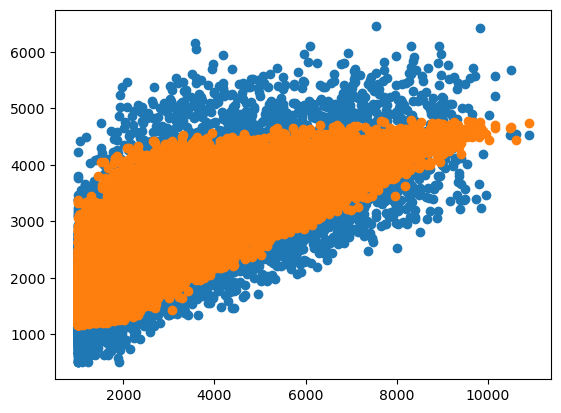

In [38]:
import matplotlib.pyplot as plt
plt.scatter(x_train['water consumption'],y_train)
plt.scatter(x_train['water consumption'],y_train_predicted)